# DLL End-Semester Practical
Done by: Siddharth Sudhakar (25901335)

## Problem Statement
### a) Triplet Loss
In representation learning (like
training face recognition models), we want to learn an embedding space where images of the same person are close together, and images
of different people are far apart. To achieve this, we use
a Triplet Loss.


A triplet consists of:
1. Anchor (A): The
reference image embedding.
2. Positive (P): A
different image embedding of the same person.
3. Negative (N): An
image embedding of a different person.

The objective is to minimize the distance between A and P, while maximizing the distance between A and N such that it is at least greater than a specified margin (m).

The mathematical formula for Triplet Margin Loss for a single triplet is:
L= max(d(A, P) - d(A, N) + m, 0)

Where d(x, y) is the Euclidean distance between vectors x and y.

Your Task:
Write a clean, self-contained
PyTorch function or class that computes the batch Triplet Loss.

Requirements:
1. Vectorization: Your implementation must compute the loss for an entire batch simultaneously. No Python for loops are allowed to iterate through the batch.
2. Mean Reduction: The function must return a single scalar value representing the average loss of the batch.
3. Validation Run: Test your function using the provided dummy data below. Print the resulting loss value.

### b) Objective
Understand regularization.

Task
Train CNN with:
- No dropout
- 0.25 dropout
- 0.5 dropout

Analyze:
- Overfitting
- Validation accuracy

Dataset: CIFAR-10

# Triplet Loss

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

Triplet Loss Class

In [2]:
class CustomTripletLoss(nn.Module):
  def __init__(self, margin=1.0):
    super(CustomTripletLoss, self).__init__() # To run the constructor of nn.Module
    self.margin = margin
  def forward(self, anchor, positive, negative):
    # Euclidean dist. between Anchor and Positive
    pos_dist = torch.norm(anchor - positive, p=2, dim=1)
    # Euclidean dist. between Anchor and Negative
    neg_dist = torch.norm(anchor - negative, p=2, dim=1)
    # Triplet Margin Loss
    loss = torch.clamp(pos_dist - neg_dist + self.margin, min=0.0)
    # Mean reduction
    return loss.mean()

Validation Data

In [3]:
batch_size = 3
embedding_dim = 4
margin = 1.0

In [4]:
# Anchor
A = torch.tensor([
[0.5, 0.1, -0.2, 0.8],
[0.1, 0.9, 0.3, 0.2],
[-0.4, -0.7, 0.1, 0.5]
], dtype=torch.float32)
# Positive
P = torch.tensor([
[0.6, 0.2, -0.1, 0.7],
[0.2, 0.8, 0.2, 0.3],
[-0.3, -0.6, 0.2, 0.4]
], dtype=torch.float32)
# Negative
N = torch.tensor([
[-0.8, 0.7, 0.9, -0.4],
[0.9, -0.1, -0.8, 0.7],
[0.5, 0.5, -0.5, -0.9]
], dtype=torch.float32)

## Result: Triplet Loss Computation

In [5]:
criterion = CustomTripletLoss(margin=margin)
loss = criterion(A, P, N)
print("TRIPLET LOSS VALIDATION")
print(f"Computed Batch Triplet Loss: {loss.item():.4f}")

TRIPLET LOSS VALIDATION
Computed Batch Triplet Loss: 0.0000


# Dropout Regularization on CIFAR-10

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("\nUsing Device:", device)


Using Device: cuda


Conversion to Tensor & Normalization of Images

In [7]:
transform = transforms.Compose([
transforms.ToTensor(),
transforms.Normalize((0.5, 0.5, 0.5),
(0.5, 0.5, 0.5))
])

## Load CIFAR-10 Dataset

In [9]:
train_dataset = torchvision.datasets.CIFAR10(
root="./data",
train=True,
download=True,
transform=transform
)

100%|██████████| 170M/170M [00:14<00:00, 11.6MB/s]


In [10]:
test_dataset = torchvision.datasets.CIFAR10(
root="./data",
train=False,
download=True,
transform=transform
)

## Train / Validation Split

In [11]:
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

In [12]:
train_dataset, val_dataset = random_split(
    train_dataset,
    [train_size, val_size]
)

Data Loaders

In [13]:
batch_size = 64

In [14]:
train_loader = DataLoader(
train_dataset,
batch_size=batch_size,
shuffle=True
)

In [15]:
val_loader = DataLoader(
val_dataset,
batch_size=batch_size,
shuffle=False
)

In [16]:
test_loader = DataLoader(
test_dataset,
batch_size=batch_size,
shuffle=False
)

## CNN Model

In [17]:
class CNN(nn.Module):
  def __init__(self, dropout_rate=0.0):
    super(CNN, self).__init__()
    self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
    self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
    self.pool = nn.MaxPool2d(2, 2)
    self.fc1 = nn.Linear(64 * 8 * 8, 512)
    self.dropout = nn.Dropout(dropout_rate)
    self.fc2 = nn.Linear(512, 10)
  def forward(self, x):
    x = self.pool(F.relu(self.conv1(x)))
    x = self.pool(F.relu(self.conv2(x)))
    x = x.view(x.size(0), -1)
    x = F.relu(self.fc1(x))
    x = self.dropout(x)
    x = self.fc2(x)
    return x

## Training Function

In [18]:
def train_model(dropout_rate, epochs=10):

    print(f"TRAINING MODEL WITH DROPOUT = {dropout_rate}")

    model = CNN(dropout_rate=dropout_rate).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):

        # TRAINING

        model.train()

        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

        # Training accuracy after full epoch
        train_accuracy = 100 * correct / total

        train_accuracies.append(train_accuracy)

        # VALIDATION

        model.eval()

        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                _, predicted = torch.max(outputs.data, 1)

                total += labels.size(0)

                correct += (predicted == labels).sum().item()

        # Validation accuracy after full validation set
        val_accuracy = 100 * correct / total

        val_accuracies.append(val_accuracy)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train Accuracy: {train_accuracy:.2f}% "
            f"Validation Accuracy: {val_accuracy:.2f}%"
        )

    return train_accuracies, val_accuracies

In [19]:
dropout_rates = [0.0, 0.25, 0.5]
results = {}
for rate in dropout_rates:
  train_acc, val_acc = train_model(rate)
  results[rate] = {
    "train_acc": train_acc,
    "val_acc": val_acc
    }

TRAINING MODEL WITH DROPOUT = 0.0
Epoch [1/10] Train Accuracy: 51.01% Validation Accuracy: 61.46%
Epoch [2/10] Train Accuracy: 65.66% Validation Accuracy: 65.06%
Epoch [3/10] Train Accuracy: 72.91% Validation Accuracy: 70.59%
Epoch [4/10] Train Accuracy: 78.64% Validation Accuracy: 71.57%
Epoch [5/10] Train Accuracy: 84.50% Validation Accuracy: 71.74%
Epoch [6/10] Train Accuracy: 89.75% Validation Accuracy: 71.91%
Epoch [7/10] Train Accuracy: 93.94% Validation Accuracy: 72.40%
Epoch [8/10] Train Accuracy: 96.34% Validation Accuracy: 72.48%
Epoch [9/10] Train Accuracy: 97.53% Validation Accuracy: 72.05%
Epoch [10/10] Train Accuracy: 97.70% Validation Accuracy: 72.48%
TRAINING MODEL WITH DROPOUT = 0.25
Epoch [1/10] Train Accuracy: 50.10% Validation Accuracy: 60.94%
Epoch [2/10] Train Accuracy: 64.74% Validation Accuracy: 65.35%
Epoch [3/10] Train Accuracy: 70.84% Validation Accuracy: 69.97%
Epoch [4/10] Train Accuracy: 75.77% Validation Accuracy: 71.14%
Epoch [5/10] Train Accuracy: 80.19

## Result: Dropout Regularization

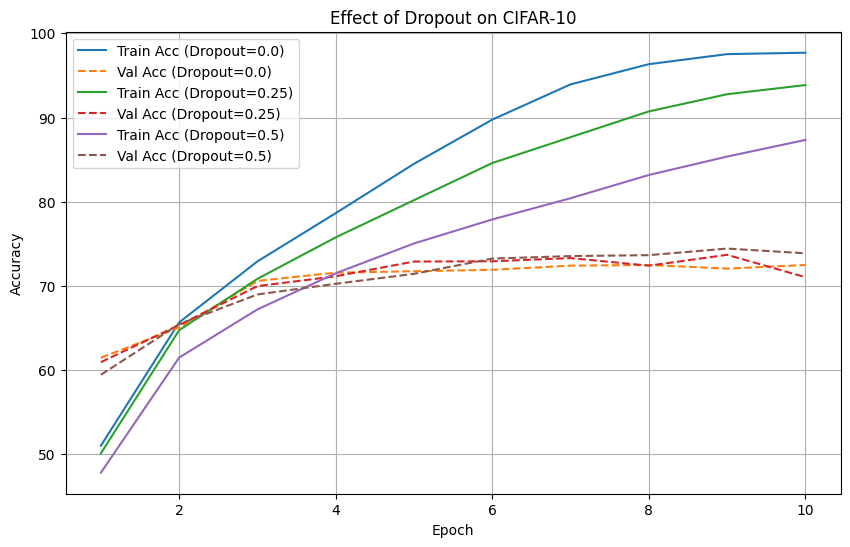

In [20]:
epochs = range(1, 11)
plt.figure(figsize=(10, 6))
for rate in dropout_rates:
  plt.plot(epochs, results[rate]["train_acc"], label=f"Train Acc (Dropout={rate})")
  plt.plot(epochs, results[rate]["val_acc"], linestyle='--', label=f"Val Acc (Dropout={rate})")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Effect of Dropout on CIFAR-10")
plt.legend()
plt.grid(True)
plt.show()

Analysis:
1. Dropout = 0.0
- High training accuracy
- More overfitting
- Validation accuracy lower
2. Dropout = 0.25
- Better generalization
- Reduced overfitting  
3. Dropout = 0.5
- Strong regularization
- Best validation accuracy